<a href="https://colab.research.google.com/github/nutangaonkar/CSL701-CE09-Machine-Learning-Lab/blob/main/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Name: Nutan Nandkishor Gaonkar                 Roll No: CE09

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [64]:
# Upload the CSV dataset to Google Colab
from google.colab import files
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Load the dataset into a DataFrame
df = pd.read_csv(filename)

# Display the first 5 records
print("First 5 records:")
display(df.head())

# Display the number of rows and columns
print("\nDataset Shape (Rows, Columns):", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Separate selling_price as the target variable
y = df["selling_price"]

# Display the first 5 target values
print("\nTarget Variable (selling_price):")
print(y.head())

Saving cardekho_dataset.csv to cardekho_dataset (3).csv
First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,Present_Price,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Dataset Shape (Rows, Columns): (15411, 14)

Column Names:
Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage',
       'Present_Price', 'max_power', 'seats', 'selling_price'],
      dtype='object')

Target Variable (selling_price):
0    120000
1    550000
2    215000
3    226000
4    570000
Name: selling_price, dtype: int64


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [66]:
# ==========================================
# TASK 3: CHECK AND HANDLE MISSING DATA
# ==========================================

# Check and count missing/null values in each column
print("Missing values in each column:")
print(df.isnull().sum())

# Calculate the total number of missing values
total_missing = df.isnull().sum().sum()
print("\nTotal missing values before preprocessing:", total_missing)

# Handle missing values only if they are present
if total_missing > 0:
    # Remove rows containing missing values
    df = df.dropna()
    print("\nMissing values found and incomplete rows were removed.")
else:
    print("\nNo missing values found. No preprocessing was required.")

# Verify that the final dataset contains no missing values
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# Display the final total number of missing values
print("\nTotal missing values after preprocessing:", df.isnull().sum().sum())

# Display the final dataset shape
print("\nFinal dataset shape:", df.shape)

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
Present_Price        0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values before preprocessing: 0

No missing values found. No preprocessing was required.

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
Present_Price        0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values after preprocessing: 0

Final dataset shape: (15411, 14)


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [67]:
# Examine all available attributes
print("Available attributes:", df.columns.tolist())

# Remove index column, car name, and target column
X = df.drop(columns=["Unnamed: 0", "car_name", "selling_price"])

# Create target vector
y = df["selling_price"]

# Record final selected features
print("\nSelected features:", X.columns.tolist())
print("Target:", y.name)

Available attributes: ['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'Present_Price', 'max_power', 'seats', 'selling_price']

Selected features: ['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'Present_Price', 'max_power', 'seats']
Target: selling_price


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [68]:
# Convert categorical variables into dummy variables
X = pd.get_dummies(
    X,
    columns=["fuel_type", "seller_type", "transmission_type"],
    drop_first=True,
    dtype=int
)

# Verify all predictors are numerical
print(X.dtypes)

# Display transformed dataset
display(X.head())

brand                            object
model                            object
vehicle_age                       int64
km_driven                         int64
mileage                         float64
Present_Price                     int64
max_power                       float64
seats                             int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Manual          int64
dtype: object


,brand,model,vehicle_age,km_driven,mileage,Present_Price,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,Maruti,Alto,9,120000,19.70,796,46.30,5,0,0,0,1,1,0,1
1,Hyundai,Grand,5,20000,18.90,1197,82.00,5,0,0,0,1,1,0,1
2,Hyundai,i20,11,60000,17.00,1197,80.00,5,0,0,0,1,1,0,1
3,Maruti,Alto,9,37000,20.92,998,67.10,5,0,0,0,1,1,0,1
4,Ford,Ecosport,6,30000,22.77,1498,98.59,5,1,0,0,0,0,0,1


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [69]:
# Create Car_Age from vehicle_age
df["Car_Age"] = df["vehicle_age"]

# Display vehicle age and new Car_Age together
display(df[["vehicle_age", "Car_Age"]].head())

# Check whether the ages are reasonable
print("Minimum Car Age:", df["Car_Age"].min())
print("Maximum Car Age:", df["Car_Age"].max())

,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6


Minimum Car Age: 0
Maximum Car Age: 29


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

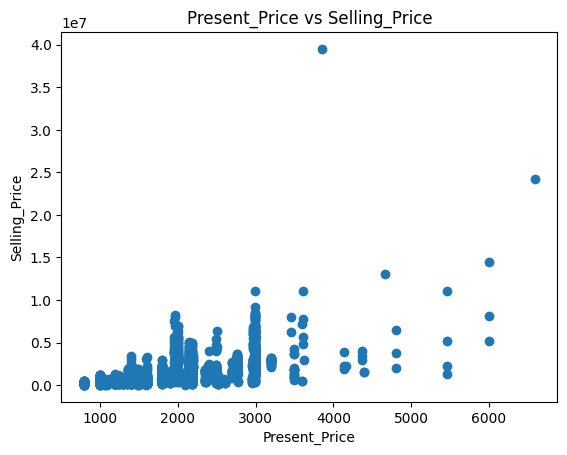

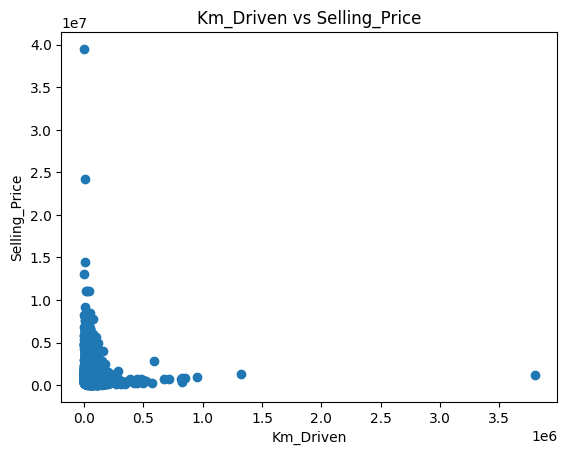

In [70]:


# Scatter Plot 1: Present_Price vs Selling_Price
plt.scatter(df["Present_Price"], df["selling_price"])
plt.xlabel("Present_Price")
plt.ylabel("Selling_Price")
plt.title("Present_Price vs Selling_Price")
plt.show()

# Scatter Plot 2: Km_Driven vs Selling_Price
plt.scatter(df["km_driven"], df["selling_price"])
plt.xlabel("Km_Driven")
plt.ylabel("Selling_Price")
plt.title("Km_Driven vs Selling_Price")
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [71]:
# ==========================================
# TASK 8: STANDARDIZE NUMERICAL FEATURES
# ==========================================

# Numerical columns to standardize
num_cols = ["vehicle_age", "km_driven", "mileage",
            "Present_Price", "max_power", "seats"]

# Temporary 80:20 split for standardization
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

# Calculate mean and standard deviation from training data only
mean = X_train[num_cols].mean()
std = X_train[num_cols].std()

# Standardize training and testing data
X_train[num_cols] = (X_train[num_cols] - mean) / std
X_test[num_cols] = (X_test[num_cols] - mean) / std

# Display mean and standard deviation
print("Training Mean:")
print(mean)

print("\nTraining Standard Deviation:")
print(std)

# Display standardized data
display(X_train[num_cols].head())

Training Mean:
vehicle_age          6.032446
km_driven        55692.819598
mileage             19.691552
Present_Price     1485.037395
max_power          100.516747
seats                5.326249
dtype: float64

Training Standard Deviation:
vehicle_age          3.018870
km_driven        54473.163748
mileage              4.172802
Present_Price      518.296985
max_power           42.745688
seats                0.809603
dtype: float64


,vehicle_age,km_driven,mileage,Present_Price,max_power,seats
3334,1.976751,0.317719,0.160192,-0.555738,-0.505706,-0.402974
10928,-0.673248,0.042354,1.844911,-0.457339,-0.620337,-0.402974
2518,0.320502,0.739946,0.258447,-0.457339,-0.275039,2.067371
11322,-1.666997,-0.939781,-0.309517,0.025010,0.440588,-0.402974
9394,1.645501,0.115785,0.002025,-1.329426,-1.268356,-0.402974


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [75]:

# Set random seed for reproducibility
np.random.seed(42)

# Randomly shuffle the row indices
indices = np.random.permutation(len(X))

# Calculate the 80% split point
split = int(0.8 * len(X))

# Split features and target while maintaining their relationship
train_idx = indices[:split]
test_idx = indices[split:]

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

# Display the number of observations
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 12328
Testing observations: 3083


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [74]:

# Create training and testing feature matrices
Xtrain = X_train
Xtest = X_test

# Create training and testing target vectors
ytrain = y_train
ytest = y_test

# Display shapes
print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)

print("\nXtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)

# Display number of predictor columns
print("\nNumber of predictor columns:", Xtrain.shape[1])

Xtrain shape: (12328, 15)
ytrain shape: (12328,)

Xtest shape: (3083, 15)
ytest shape: (3083,)

Number of predictor columns: 15


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [76]:


# Add one column of 1.0 as the bias/intercept column
Xtrain_bias = np.column_stack((np.ones(Xtrain.shape[0]), Xtrain))
Xtest_bias = np.column_stack((np.ones(Xtest.shape[0]), Xtest))

# Display new matrix dimensions
print("Xtrain with bias:", Xtrain_bias.shape)
print("Xtest with bias:", Xtest_bias.shape)

# Verify the bias column
print("\nFirst 5 bias values:")
print(Xtrain_bias[:5, 0])

Xtrain with bias: (12328, 16)
Xtest with bias: (3083, 16)

First 5 bias values:
[1.0 1.0 1.0 1.0 1.0]


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [81]:
# ==========================================
# TASK 12: IMPLEMENT OLS FUNCTION
# ==========================================

def ols(X, y):

    # Calculate XᵀX
    XTX = X.T @ X

    # Calculate Xᵀy
    XTy = X.T @ y

    # Calculate regression coefficients
    beta = np.linalg.pinv(XTX) @ XTy

    return beta


# Apply OLS function
beta = ols(Xtrain_bias, ytrain.to_numpy())

print("Number of coefficients:", len(beta))

Number of coefficients: 160


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [83]:

# Calculate XᵀX
XTX = Xtrain_bias.T @ Xtrain_bias

# Calculate determinant
det = np.linalg.det(XTX)

# Calculate matrix rank
rank = np.linalg.matrix_rank(XTX)

# Number of columns in XTX
columns = XTX.shape[0]

# Display results
print("Determinant of XTX:", det)
print("Rank:", rank)
print("Number of columns:", columns)

# Check whether the matrix is singular
if rank < columns:
    print("\nXTX is singular.")
    print("Redundant or linearly dependent features are present.")
else:
    print("\nXTX is non-singular.")
    print("The matrix is suitable for the normal equation.")

Determinant of XTX: 0.0
Rank: 117
Number of columns: 160

XTX is singular.
Redundant or linearly dependent features are present.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [85]:

# Recreate training and testing feature DataFrames
# with categorical variables converted to numerical values
Xtrain_df = pd.get_dummies(X_train, drop_first=True, dtype=float)
Xtest_df = pd.get_dummies(X_test, drop_first=True, dtype=float)

# Make sure both datasets have identical columns
Xtrain_df, Xtest_df = Xtrain_df.align(
    Xtest_df,
    join="left",
    axis=1,
    fill_value=0
)

# Save the actual feature names BEFORE converting to NumPy
feature_names = list(Xtrain_df.columns)

# Convert DataFrames to NumPy arrays
Xtrain_array = Xtrain_df.to_numpy(dtype=float)
Xtest_array = Xtest_df.to_numpy(dtype=float)

# Add bias/intercept column
Xtrain_bias = np.column_stack(
    (np.ones(Xtrain_array.shape[0]), Xtrain_array)
)

Xtest_bias = np.column_stack(
    (np.ones(Xtest_array.shape[0]), Xtest_array)
)

# Train the model using the OLS function
beta = ols(Xtrain_bias, ytrain.to_numpy())

# Display intercept
print("Intercept (β0):", beta[0])

# Create coefficient table using ACTUAL feature names
coefficients = pd.DataFrame({
    "Feature": ["Intercept"] + feature_names,
    "Coefficient": beta
})

display(coefficients)

Intercept (β0): 3014984.2730234265


,Feature,Coefficient
0,Intercept,3.014984e+06
1,vehicle_age,-7.964871e+04
2,km_driven,-4.927886e-01
3,mileage,-2.412311e+03
4,Present_Price,-1.597760e+02
...,...,...
155,model_Yaris,-6.674413e+05
156,model_Z4,2.003887e+06
157,model_i10,-1.736600e+05
158,model_i20,-2.665796e+05


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [86]:


# Identify positive and negative coefficients
positive = coefficients[coefficients["Coefficient"] > 0]
negative = coefficients[coefficients["Coefficient"] < 0]

print("Number of Positive Coefficients:", len(positive))
print("Number of Negative Coefficients:", len(negative))

# Display the features with the largest coefficient influence
print("\nTop 10 Features by Absolute Coefficient Value:")

influence = coefficients.iloc[1:].copy()  # Exclude intercept
influence["Absolute_Coefficient"] = influence["Coefficient"].abs()

display(
    influence.sort_values(
        by="Absolute_Coefficient",
        ascending=False
    ).head(10)
)

Number of Positive Coefficients: 54
Number of Negative Coefficients: 106

Top 10 Features by Absolute Coefficient Value:


,Feature,Coefficient,Absolute_Coefficient
17,brand_Ferrari,1.694644e+07,1.694644e+07
92,model_GTC4Lusso,1.694644e+07,1.694644e+07
15,brand_Bentley,4.890129e+06,4.890129e+06
70,model_Continental,4.890129e+06,4.890129e+06
147,model_XC,3.186852e+06,3.186852e+06
145,model_X4,3.159616e+06,3.159616e+06
90,model_GLS,2.721442e+06,2.721442e+06
44,model_6,2.626158e+06,2.626158e+06
148,model_XC60,-2.444149e+06,2.444149e+06
146,model_X5,2.122334e+06,2.122334e+06


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [87]:


# Predict selling prices for the test dataset
y_pred = Xtest_bias @ beta

# Create a comparison table
comparison = pd.DataFrame({
    "Actual Selling Price": ytest.to_numpy(),
    "Predicted Selling Price": y_pred
})

# Display the first 10 predictions
display(comparison.head(10))

,Actual Selling Price,Predicted Selling Price
0,4450000,2.244716e+06
1,1290000,1.434567e+06
2,485000,4.477861e+05
3,400000,4.288229e+05
4,800000,7.984540e+05
5,150000,-2.559015e+05
6,650000,7.045769e+05
7,325000,-3.874848e+04
8,300000,3.348677e+05
9,925000,1.097817e+06


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [88]:

# Calculate residuals (prediction errors)
residuals = ytest.to_numpy() - y_pred

# Calculate Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

# Display RSS
print("Residual Sum of Squares (RSS):", RSS)

# Display first 10 residuals
print("\nFirst 10 Prediction Errors:")
print(residuals[:10])

Residual Sum of Squares (RSS): 969694744755283.1

First 10 Prediction Errors:
[ 2.20528385e+06 -1.44566704e+05  3.72138887e+04 -2.88229341e+04
  1.54603488e+03  4.05901505e+05 -5.45768561e+04  3.63748483e+05
 -3.48676874e+04 -1.72817210e+05]


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [89]:


# Convert actual values to NumPy array
y_actual = ytest.to_numpy()

# Calculate the mean of actual selling prices
y_mean = np.mean(y_actual)

# Calculate Total Sum of Squares (TSS)
TSS = np.sum((y_actual - y_mean) ** 2)

# Calculate R²
R2 = 1 - (RSS / TSS)

# Display results
print("Total Sum of Squares (TSS):", TSS)
print("R² Score:", R2)

Total Sum of Squares (TSS): 2407385049859876.5
R² Score: 0.5971999806131034


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


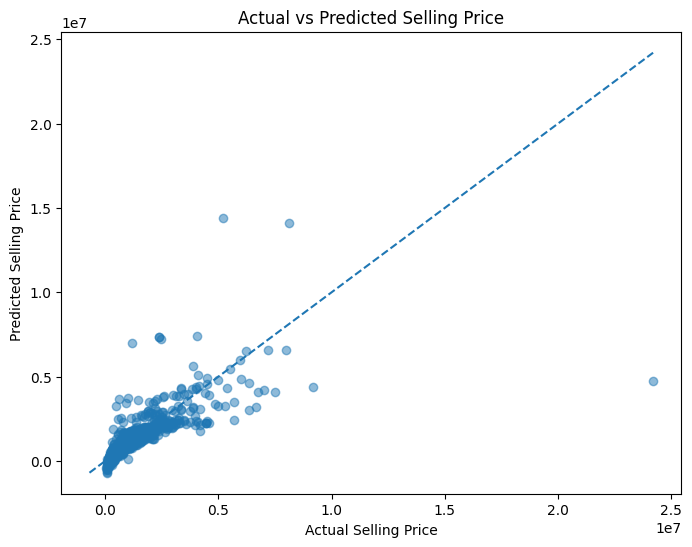

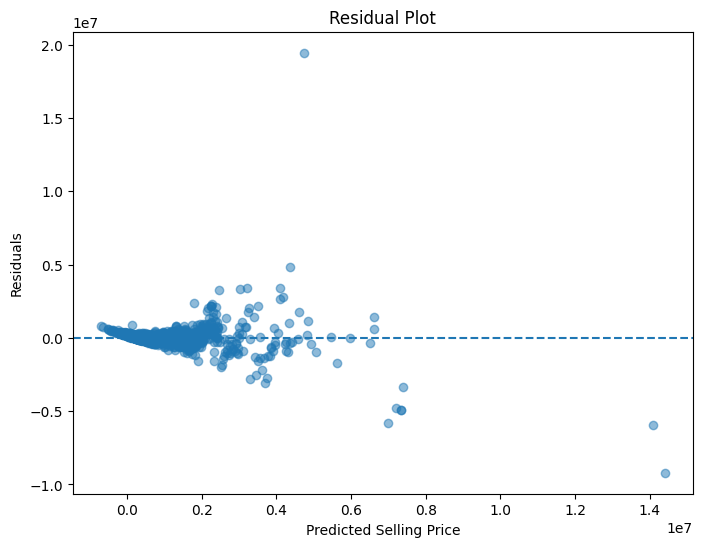

Top 10 Observations with Largest Prediction Errors:


,Actual Selling Price,Predicted Selling Price,Residual,Absolute Error
2796,24200000,4.736160e+06,1.946384e+07,1.946384e+07
2050,5200000,1.440243e+07,-9.202432e+06,9.202432e+06
1552,8100000,1.407936e+07,-5.979359e+06,5.979359e+06
2120,1200000,6.997023e+06,-5.797023e+06,5.797023e+06
2439,2400000,7.343214e+06,-4.943214e+06,4.943214e+06
867,2400000,7.341302e+06,-4.941302e+06,4.941302e+06
2362,9200000,4.363045e+06,4.836955e+06,4.836955e+06
1243,2450000,7.215272e+06,-4.765272e+06,4.765272e+06
1092,6645000,3.219923e+06,3.425077e+06,3.425077e+06
841,7500000,4.096580e+06,3.403420e+06,3.403420e+06


In [90]:


# Actual values
y_actual = ytest.to_numpy()

# ------------------------------------------
# 1. Actual vs Predicted Selling Price Plot
# ------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(y_actual, y_pred, alpha=0.5)

# Perfect prediction reference line
min_value = min(y_actual.min(), y_pred.min())
max_value = max(y_actual.max(), y_pred.max())

plt.plot([min_value, max_value],
         [min_value, max_value],
         linestyle="--")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()


# ------------------------------------------
# 2. Residual Plot
# ------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


# ------------------------------------------
# 3. Identify Large Prediction Errors
# ------------------------------------------

error_analysis = pd.DataFrame({
    "Actual Selling Price": y_actual,
    "Predicted Selling Price": y_pred,
    "Residual": residuals,
    "Absolute Error": np.abs(residuals)
})

# Display top 10 largest prediction errors
large_errors = error_analysis.sort_values(
    by="Absolute Error",
    ascending=False
).head(10)

print("Top 10 Observations with Largest Prediction Errors:")

display(large_errors)

### Task 20: Conclude
Most Influential Features

Based on the regression coefficients, features related to car brand and model had the greatest influence on the predicted selling price. Some of the most influential features included brand_Ferrari, model_GTC4Lusso, brand_Bentley, and model_Continental. The numerical features such as vehicle_age, km_driven, mileage, Present_Price, max_power, and seats also contributed to the prediction.

Advantages of Multiple Linear Regression
It is simple and easy to understand.
It can use multiple features to predict selling price.
Regression coefficients help identify influential features.
It is computationally efficient.

Limitations of Multiple Linear Regression
It assumes a linear relationship between the features and selling price.
Multicollinearity and redundant features can affect the model.
Extreme or luxury cars can result in large prediction errors.
The model may sometimes produce unrealistic predictions, such as negative prices.
Some important factors affecting car prices may not be included in the dataset.


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.